# Image Denoising with a Convolutional Autoencoder — MNIST

### 1. Setup

In [ ]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


### 2. Load and Preprocess MNIST


In [ ]:
transform = transforms.ToTensor()

train_full = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

val_size = int(0.1 * len(train_full))
train_size = len(train_full) - val_size
train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 471kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

Train: 54000 | Val: 6000 | Test: 10000


In [ ]:
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape, "| dtype:", xb.dtype, "| min/max:", xb.min().item(), xb.max().item())


Batch shape: torch.Size([256, 1, 28, 28]) | dtype: torch.float32 | min/max: 0.0 1.0


### 3. Corrupt Images with Gaussian Noise

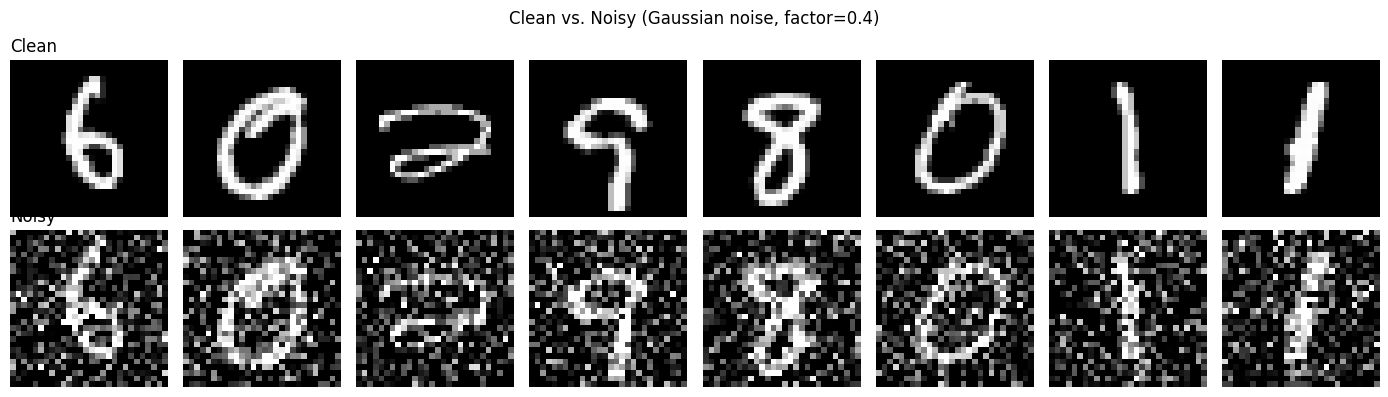

In [ ]:
def add_gaussian_noise(images, noise_factor=0.4):
    """Add Gaussian noise to a batch of images, then clip to a valid pixel range."""
    noisy = images + noise_factor * torch.randn_like(images)
    return torch.clamp(noisy, 0.0, 1.0)

NOISE_FACTOR = 0.4  # try values between 0.2 (mild) and 0.6 (heavy)

sample_x, _ = next(iter(train_loader))
sample_x = sample_x[:8]
sample_noisy = add_gaussian_noise(sample_x, NOISE_FACTOR)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(sample_x[i].squeeze(), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(sample_noisy[i].squeeze(), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("Clean", loc="left", fontsize=12)
axes[1, 0].set_title("Noisy", loc="left", fontsize=12)
plt.suptitle(f"Clean vs. Noisy (Gaussian noise, factor={NOISE_FACTOR})")
plt.tight_layout()
plt.show()


In [ ]:
### 4. Build the Denoising Autoencoder

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()
        # Encoder: 28x28x1 -> 14x14x32 -> 7x7x64
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, latent_channels, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        # Decoder: 7x7x64 -> 14x14x32 -> 28x28x1
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


model = DenoisingAutoencoder().to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {n_params:,}")


DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

Total trainable parameters: 37,569


### 5. Training Setup

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 15

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, _ in loader:
            images = images.to(device)
            noisy_images = add_gaussian_noise(images, NOISE_FACTOR)

            outputs = model(noisy_images)
            loss = criterion(outputs, images)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

start = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_denoising_ae.pt")
        marker = "  (saved best model)"

    print(f"Epoch {epoch:2d}/{EPOCHS} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}{marker}")

print(f"\nTraining complete in {time.time()-start:.1f}s. Best val_loss={best_val_loss:.5f}")


Epoch  1/15 | train_loss=0.04445 | val_loss=0.01124  (saved best model)
Epoch  2/15 | train_loss=0.01030 | val_loss=0.00976  (saved best model)
Epoch  3/15 | train_loss=0.00959 | val_loss=0.00942  (saved best model)
Epoch  4/15 | train_loss=0.00930 | val_loss=0.00918  (saved best model)
Epoch  5/15 | train_loss=0.00909 | val_loss=0.00903  (saved best model)
Epoch  6/15 | train_loss=0.00892 | val_loss=0.00892  (saved best model)
Epoch  7/15 | train_loss=0.00880 | val_loss=0.00870  (saved best model)
Epoch  8/15 | train_loss=0.00869 | val_loss=0.00863  (saved best model)
Epoch  9/15 | train_loss=0.00862 | val_loss=0.00855  (saved best model)
Epoch 10/15 | train_loss=0.00851 | val_loss=0.00846  (saved best model)
Epoch 11/15 | train_loss=0.00843 | val_loss=0.00843  (saved best model)
Epoch 12/15 | train_loss=0.00838 | val_loss=0.00832  (saved best model)
Epoch 13/15 | train_loss=0.00834 | val_loss=0.00836
Epoch 14/15 | train_loss=0.00828 | val_loss=0.00823  (saved best model)
Epoch 15/15 

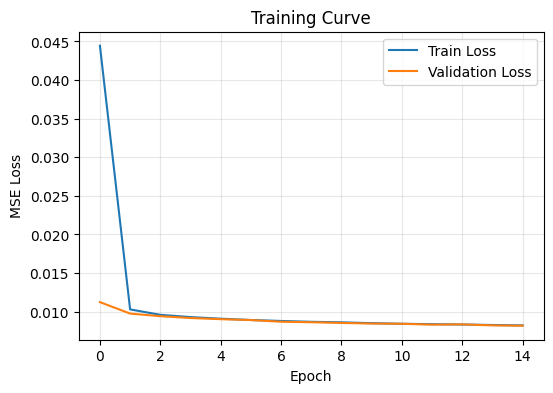

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### 6. Generate Denoised Outputs on the Test Set

In [ ]:
model.load_state_dict(torch.load("best_denoising_ae.pt", map_location=device))
model.eval()

test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)
test_noisy = add_gaussian_noise(test_images, NOISE_FACTOR)

with torch.no_grad():
    test_denoised = model(test_noisy)

test_images_np   = test_images.cpu().numpy()
test_noisy_np    = test_noisy.cpu().numpy()
test_denoised_np = test_denoised.cpu().numpy()


### 7. Result Visualization

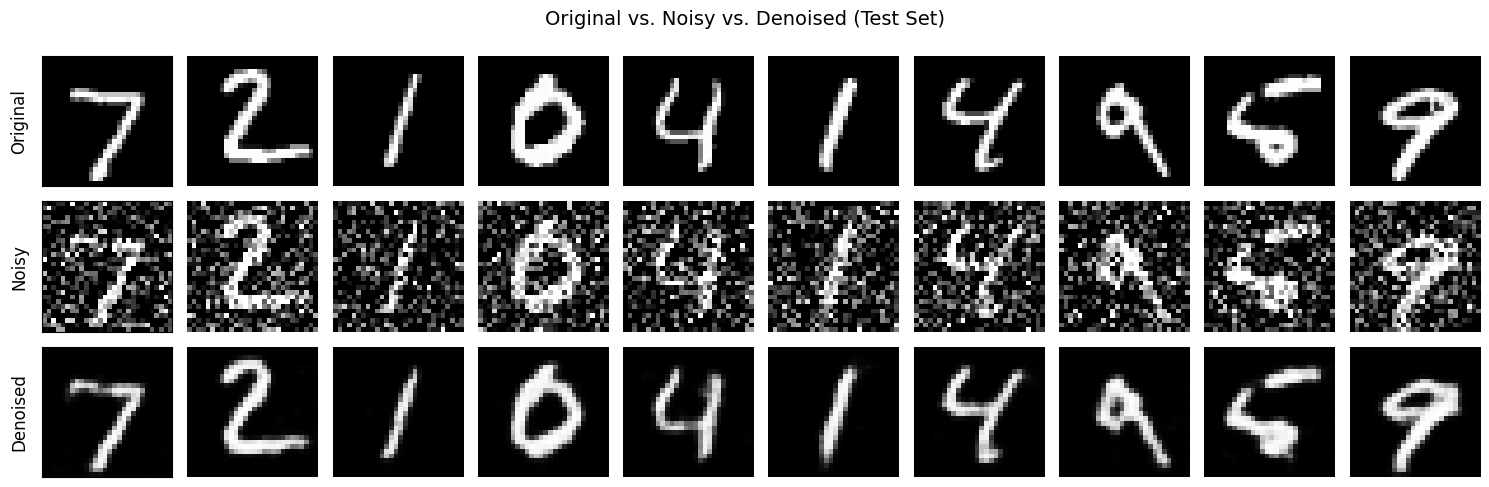

In [ ]:
N_SAMPLES = 10
fig, axes = plt.subplots(3, N_SAMPLES, figsize=(1.5 * N_SAMPLES, 5))
row_labels = ["Original", "Noisy", "Denoised"]
data_rows = [test_images_np, test_noisy_np, test_denoised_np]

for row in range(3):
    for col in range(N_SAMPLES):
        ax = axes[row, col]
        ax.imshow(data_rows[row][col].squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(row_labels[row], fontsize=12, rotation=90, labelpad=10)

plt.suptitle("Original vs. Noisy vs. Denoised (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
### 7. Quantitative Evaluation: PSNR & SSIM


In [ ]:
@torch.no_grad()
def evaluate_full_test_set():
    psnr_noisy, psnr_denoised = [], []
    ssim_noisy, ssim_denoised = [], []

    for images, _ in test_loader:
        images = images.to(device)
        noisy = add_gaussian_noise(images, NOISE_FACTOR)
        denoised = model(noisy)

        images_np   = images.cpu().numpy()
        noisy_np    = noisy.cpu().numpy()
        denoised_np = denoised.cpu().numpy()

        for i in range(images_np.shape[0]):
            clean_img = images_np[i, 0]
            noisy_img = noisy_np[i, 0]
            denoised_img = denoised_np[i, 0]

            psnr_noisy.append(psnr_metric(clean_img, noisy_img, data_range=1.0))
            psnr_denoised.append(psnr_metric(clean_img, denoised_img, data_range=1.0))
            ssim_noisy.append(ssim_metric(clean_img, noisy_img, data_range=1.0))
            ssim_denoised.append(ssim_metric(clean_img, denoised_img, data_range=1.0))

    return {
        "PSNR_noisy_mean": np.mean(psnr_noisy),
        "PSNR_denoised_mean": np.mean(psnr_denoised),
        "SSIM_noisy_mean": np.mean(ssim_noisy),
        "SSIM_denoised_mean": np.mean(ssim_denoised),
    }

metrics = evaluate_full_test_set()
print("=== Full Test-Set Metrics (higher = better for both) ===")
print(f"PSNR   noisy  vs clean : {metrics['PSNR_noisy_mean']:.2f} dB")
print(f"PSNR denoised vs clean : {metrics['PSNR_denoised_mean']:.2f} dB")
print(f"SSIM   noisy  vs clean : {metrics['SSIM_noisy_mean']:.4f}")
print(f"SSIM denoised vs clean : {metrics['SSIM_denoised_mean']:.4f}")


=== Full Test-Set Metrics (higher = better for both) ===
PSNR   noisy  vs clean : 11.00 dB
PSNR denoised vs clean : 21.18 dB
SSIM   noisy  vs clean : 0.4461
SSIM denoised vs clean : 0.8863


In [ ]:
### 9. Stress Test: Performance Across Noise Levels

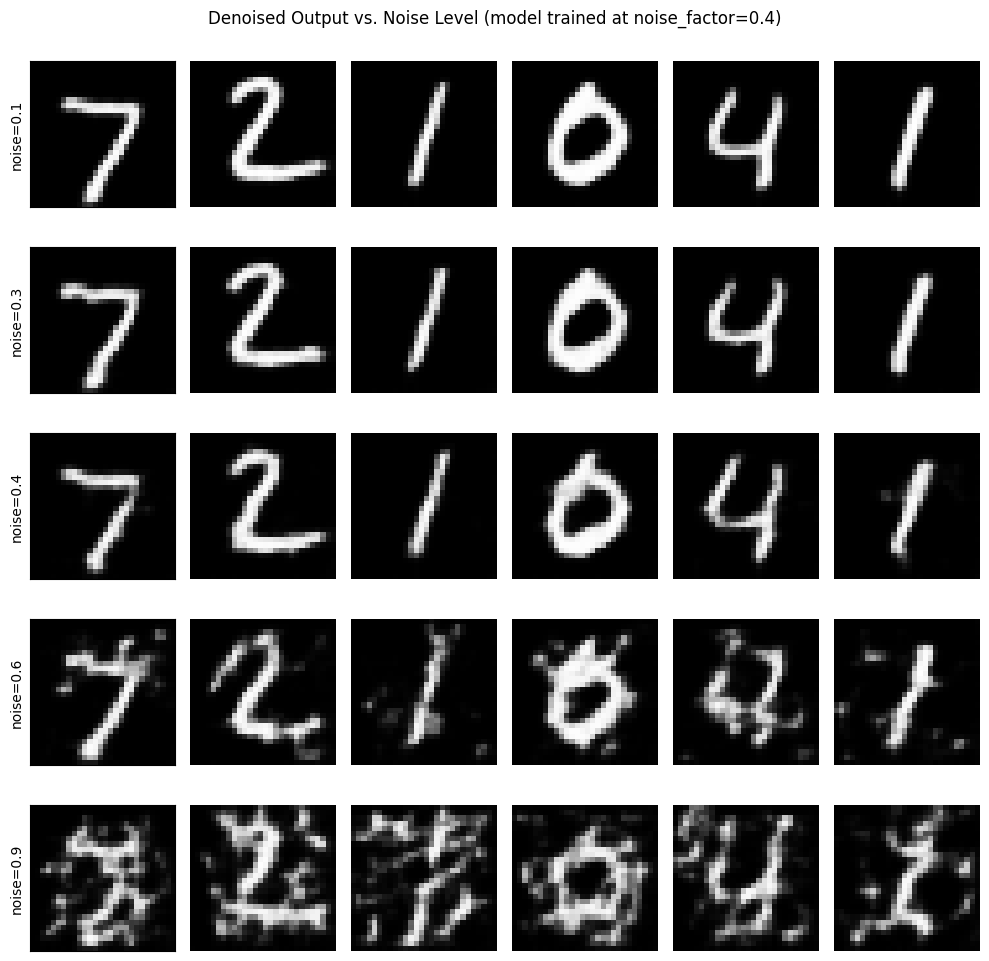

In [ ]:
noise_levels_to_test = [0.1, 0.3, 0.4, 0.6, 0.9]

fig, axes = plt.subplots(len(noise_levels_to_test), 6, figsize=(10, 2 * len(noise_levels_to_test)))
sample_clean, _ = next(iter(test_loader))
sample_clean = sample_clean[:6].to(device)

with torch.no_grad():
    for row, nf in enumerate(noise_levels_to_test):
        noisy_sample = add_gaussian_noise(sample_clean, noise_factor=nf)
        denoised_sample = model(noisy_sample)
        for col in range(6):
            axes[row, col].imshow(denoised_sample[col].cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
            axes[row, col].axis("off")
        axes[row, 0].axis("on")
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        axes[row, 0].set_ylabel(f"noise={nf}", rotation=90, fontsize=10)

plt.suptitle("Denoised Output vs. Noise Level (model trained at noise_factor=0.4)")
plt.tight_layout()
plt.show()


### 10. Conclusion

This notebook built an end-to-end denoising pipeline: loading MNIST,
synthetically corrupting it with Gaussian noise, training a convolutional
autoencoder to map noisy → clean, and evaluating the result both visually
and with objective PSNR/SSIM metrics. The model reliably removes noise while
retaining digit identity, with the main remaining failure mode being
over-smoothing at high noise levels — a well-known limitation of plain
MSE-trained autoencoders, and a natural starting point for the extensions
listed above.
